<a href="https://colab.research.google.com/github/israakadhem0-coder/Drug-discovery_ML/blob/main/bioactivity_prediction_app.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **QSAR Model Building of NRF2 **



# Read in data

In [6]:
import pandas as pd

In [7]:
df = pd.read_csv('/content/NRF2_Keap1_06_bioactivity_data_3class_pIC50_pubchem_fp.csv')

In [8]:
X = df.drop(['pIC50'], axis=1)
X

,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,PubchemFP9,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,1,1,1,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,1,1,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,1,1,1,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
156,1,1,1,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
157,1,1,1,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
158,1,1,1,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [9]:
Y = df.iloc[:,-1]
Y

,pIC50
0,3.928118
1,7.481486
2,7.698970
3,3.602060
4,7.356547
...,...
155,6.638272
156,6.193820
157,7.236572
158,7.193820


# Remove low variance features

In [10]:
from sklearn.feature_selection import VarianceThreshold

def remove_low_variance(input_data, threshold=0.1):
    selection = VarianceThreshold(threshold)
    selection.fit(input_data)
    return input_data[input_data.columns[selection.get_support(indices=True)]]

X = remove_low_variance(X, threshold=0.1)
X

,PubchemFP3,PubchemFP13,PubchemFP16,PubchemFP21,PubchemFP33,PubchemFP34,PubchemFP143,PubchemFP145,PubchemFP146,PubchemFP192,...,PubchemFP791,PubchemFP797,PubchemFP798,PubchemFP800,PubchemFP805,PubchemFP812,PubchemFP818,PubchemFP820,PubchemFP821,PubchemFP833
0,0,0,0,0,1,1,0,0,0,1,...,0,1,0,0,0,0,0,1,1,0
1,0,1,1,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,1,1,1,0,0,0,1,...,1,0,0,1,0,0,1,0,1,0
3,1,1,0,1,1,1,0,0,0,1,...,1,0,0,1,0,0,1,0,1,0
4,0,0,1,1,1,1,0,0,0,1,...,1,0,0,1,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,1,1,0,1,1,1,1,1,1,1,...,0,1,1,0,0,1,0,1,1,0
156,1,1,0,1,1,1,1,1,1,1,...,0,1,1,0,0,1,0,1,1,0
157,1,1,1,1,1,1,1,1,1,1,...,0,1,1,0,0,1,0,1,1,0
158,1,1,1,1,1,1,1,1,1,1,...,0,0,1,0,0,1,0,0,1,0


In [11]:
X.to_csv('descriptor_list.csv', index = False)

In [ ]:
# In the app, use the following to get this same descriptor list
# of 218 variables from the initial set of 881 variables
# Xlist = list(pd.read_csv('descriptor_list.csv').columns)
# X[Xlist]

# Random Forest Regression Model

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [13]:
model = RandomForestRegressor(n_estimators=500, random_state=42)
model.fit(X, Y)
r2 = model.score(X, Y)
r2

0.9101971500793188

## Model Prediction

In [14]:
Y_pred = model.predict(X)
Y_pred

array([4.36689124, 6.8132317 , 7.03978742, 4.81839735, 7.05594922,
       6.4082986 , 6.91678578, 6.51290301, 4.11011974, 3.2920437 ,
       6.46649612, 6.22022995, 6.70391021, 6.85293869, 6.85293869,
       7.83156588, 7.56061764, 7.03706194, 6.13819256, 6.06562879,
       5.51533823, 7.37338919, 6.9058196 , 6.46428316, 6.73511946,
       6.56869582, 6.67594672, 6.61389989, 6.64205728, 7.03978742,
       5.0134465 , 4.79049689, 6.13819256, 6.85293869, 7.37338919,
       7.37338919, 7.5273545 , 6.85293869, 6.85293869, 4.81786798,
       4.67090962, 5.92380078, 4.67090962, 5.92380078, 5.30840155,
       5.30840155, 5.23476299, 5.23476299, 5.23476299, 5.06197371,
       5.86073501, 5.26341549, 6.02925582, 4.33594073, 4.90173775,
       4.42214784, 4.59638632, 4.59638632, 4.61629737, 4.4454519 ,
       4.4454519 , 4.4454519 , 4.36328054, 4.39799269, 4.26087923,
       4.26087923, 6.85293869, 7.07693589, 7.74813113, 3.30878773,
       3.89574979, 4.11011974, 4.11011974, 3.80892643, 4.30754

## Model Performance

In [15]:
print('Mean squared error (MSE): %.2f'
      % mean_squared_error(Y, Y_pred))
print('Coefficient of determination (R^2): %.2f'
      % r2_score(Y, Y_pred))

Mean squared error (MSE): 0.18
Coefficient of determination (R^2): 0.91


# Data Visualization (Experimental vs Predicted pIC50 for Training Data)

In [16]:
import matplotlib.pyplot as plt
import numpy as np

Text(0.5, 0, 'Experimental pIC50')

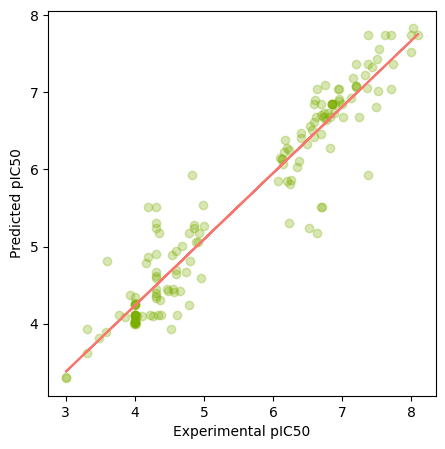

In [17]:
plt.figure(figsize=(5,5))
plt.scatter(x=Y, y=Y_pred, c="#7CAE00", alpha=0.3)

# Add trendline
# https://stackoverflow.com/questions/26447191/how-to-add-trendline-in-python-matplotlib-dot-scatter-graphs
z = np.polyfit(Y, Y_pred, 1)
p = np.poly1d(z)

plt.plot(Y,p(Y),"#F8766D")
plt.ylabel('Predicted pIC50')
plt.xlabel('Experimental pIC50')

# Save Model as Pickle Object

In [18]:
import pickle

In [19]:
pickle.dump(model, open('NRF2_Keap1_model.pkl', 'wb'))